# Ordinal Classification with Ordinal Logistic Regression

In this notebook, we'll:

- Introduce **ordinal classification** and its importance.
- Use the **Wine Quality** dataset as an example.
- Implement **Ordinal Logistic Regression** using the `mord` library.
- Evaluate the model using appropriate metrics like **Mean Absolute Error (MAE)** and **Quadratic Weighted Kappa (QWK)**.
- Visualize and interpret the results.

## Table of Contents

1. [Introduction](#scrollTo=wgyxz23kveT2)
2. [Import Libraries](#scrollTo=ajSc4WREvqqx)
3. [Load and Explore the Data](#scrollTo=tVe6yxu-vy-V)
4. [Data Preprocessing](#scrollTo=neKyOMkywbKQ)
5. [Ordinal Logistic Regression](#scrollTo=saiB-CF-woiJ)
6. [Model Evaluation](#scrollTo=wD64kDqrw3K4)
    - [Mean Absolute Error (MAE)](#scrollTo=ZQxAgsG9w4Ta)
    - [Quadratic Weighted Kappa (QWK)](#scrollTo=WB2-9LgVxAGZ)
7. [Conclusion](#scrollTo=htKAGeWbxUfs)

## Introduction

### What is Ordinal Classification?

**Ordinal classification** (or ordinal regression) deals with predicting categories that have a natural, ordered relationship. Unlike nominal classification (where classes are unordered) and regression (where outputs are continuous), ordinal classification predicts labels that are discrete and ordered.


**Examples of ordinal variables:**

- Movie ratings (e.g., 1 star to 5 stars)
- Customer satisfaction levels (e.g., "Very Unsatisfied" to "Very Satisfied")
- Wine quality ratings (e.g., scores from 0 to 10)

### Objective

We aim to predict the quality of wine based on its physicochemical properties using ordinal classification techniques.


---



## Import Libraries

In [20]:
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, confusion_matrix, classification_report

# Import Ordinal Logistic Regression from the mord package
!pip install mord
from mord import LogisticIT

# For Quadratic Weighted Kappa
from sklearn.metrics import cohen_kappa_score

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Load and Explore the Data

We'll use the **Wine Quality** dataset from the UCI Machine Learning Repository.

### Load the Dataset

In [21]:
# Load the dataset directly from the URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(url, sep=';')

### Explore the Dataset

In [22]:
# Display the first five rows
display(data.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [23]:
# Summary statistics
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Check for Missing Values

In [24]:
# Check for null values
data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


**Observation**: No missing values in the dataset.

### Target Variable Distribution

In [25]:
# Distribution of the 'quality' variable
quality_counts = data['quality'].value_counts().sort_index()
print("Quality Counts:\n", quality_counts)

Quality Counts:
 quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


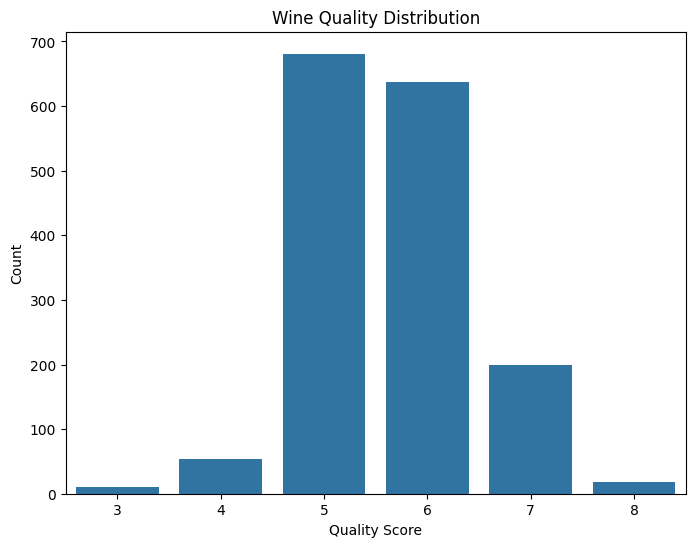

In [26]:
# Plot the distribution
plt.figure(figsize=(8,6))
sns.countplot(x='quality', data=data)
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

**Observation**: The quality scores range from 3 to 8, with most wines rated between 5 and 6.


---

## Data Preprocessing


### Feature Matrix and Target Vector


In [27]:
X = data.drop('quality', axis=1)
y = data['quality']

### Split into Training and Testing Sets

We'll use stratified splitting to maintain the distribution of quality scores in both training and testing sets.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### Feature Scaling

In [29]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---

## Ordinal Logistic Regression

### Introduction to Ordinal Logistic Regression

**Ordinal Logistic Regression** is a type of regression model used for predicting an ordinal variable. It extends the logistic regression model to handle ordered categorical variables by modeling the cumulative probabilities of the categories.

We'll use the `LogisticIT` model from the `mord` library, which implements an ordinal logistic regression with proportional odds.


### Train the Model

In [30]:
# Initialize the Ordinal Logistic Regression model
model = LogisticIT()

# Train the model
model.fit(X_train, y_train)

LogisticIT()

### Predictions on the Test Set

In [32]:
# Predictions
y_pred = model.predict(X_test)

## Model Evaluation

### Mean Absolute Error (MAE)

**Mean Absolute Error (MAE)** measures the average magnitude of errors between predicted and actual values.


In [33]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error (MAE):', mae)

Mean Absolute Error (MAE): 0.428125


**Interpretation**: A lower MAE indicates better model performance.

### Quadratic Weighted Kappa (QWK)

**Quadratic Weighted Kappa (QWK)** measures the agreement between two ratings. It ranges from -1 (complete disagreement) to 1 (complete agreement). It penalizes larger discrepancies more than smaller ones.

In [34]:
from sklearn.metrics import cohen_kappa_score

# Calculate Quadratic Weighted Kappa
qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print('Quadratic Weighted Kappa (QWK):', qwk)

Quadratic Weighted Kappa (QWK): 0.5072912941550443


**Interpretation**: A higher QWK indicates better agreement between predicted and actual quality scores.


### Confusion Matrix


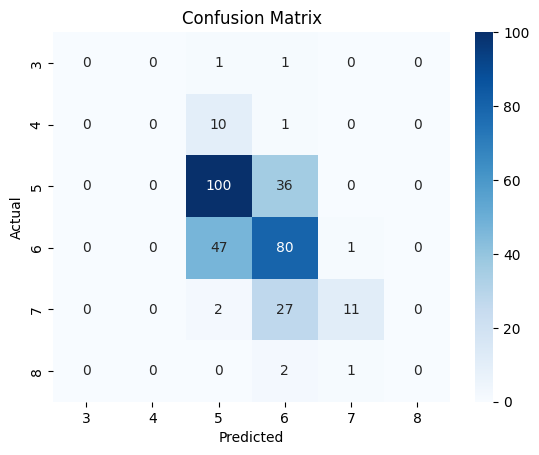

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
disp = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Observation**: The confusion matrix shows that most predictions are close to the actual values, indicating the model respects the ordinal nature of the data.

### Classification Report

In [36]:
print('Classification Report:\n')
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.74      0.68       136
           6       0.54      0.62      0.58       128
           7       0.85      0.28      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.60       320
   macro avg       0.34      0.27      0.28       320
weighted avg       0.59      0.60      0.57       320



**Note**: While precision, recall, and F1-score are not ideal for ordinal data, they provide insight into the model's performance for each class.


---

## Conclusion

- **Ordinal Classification**: Successfully built an ordinal logistic regression model to predict wine quality ratings.
- **Evaluation Metrics**:
    - **Mean Absolute Error (MAE)**: Provided an average magnitude of prediction errors.
    - **Quadratic Weighted Kappa (QWK)**: Measured the agreement between predicted and actual ratings, accounting for the ordinal nature.
- **Model Performance**:
    - The model achieved a relatively low MAE and a reasonable QWK score, indicating good performance in predicting ordered categories.
    - The confusion matrix showed that most predictions are close to the actual ratings, respecting the order.

**Key Takeaways**:

- **Ordinal Logistic Regression** is suitable for predicting ordered categorical variables.
- Using appropriate evaluation metrics is crucial for ordinal classification tasks.
- The `mord` library provides easy-to-use implementations of ordinal regression models.

---

**Encouragement**:

Exploring ordinal classification allows you to handle problems where the target variable has a natural order. By understanding and applying ordinal regression techniques, you're enhancing your ability to build models that respect the inherent structure of your data. Keep experimenting with different datasets and models to deepen your machine learning expertise!

---